# LangGraph Tracing Demo

This notebook is optimized for live delivery with minimal steps.

Audience outcomes:

- See end-to-end tracing for a LangGraph agent
- Compare normal and failure runs
- Use real LLM calls and real tool APIs
- Understand token and cost telemetry


## 1. Setup (Run Once)

Run the next setup cells once before the demo flow.

This keeps setup simple and avoids switching between many diagnostics cells.

What setup does:

- adds local `code/` imports
- enables quiet logging
- installs required packages (quiet mode)
- loads tracing environment
- initializes tracer and agent


In [1]:
# Setup once: imports, local module path, and quiet logging
import os
import sys
import logging
import http.client
from pathlib import Path

# Resolve project root and add local code/ path
project_root = Path.cwd()
code_dir = project_root / "code"
if str(code_dir) not in sys.path:
    sys.path.insert(0, str(code_dir))

# Quiet mode: suppress verbose SDK/HTTP/API logs
for logger_name in [
    "azure",
    "azure.core.pipeline.policies.http_logging_policy",
    "azure.monitor",
    "urllib3",
    "requests",
    "httpx",
    "opentelemetry",
]:
    logging.getLogger(logger_name).setLevel(logging.WARNING)

http.client.HTTPConnection.debuglevel = 0
os.environ["AZURE_LOG_LEVEL"] = "WARNING"

print(f"Project root: {project_root}")
print(f"Code path added: {code_dir}")
print("Quiet logging mode enabled.")

Project root: /Users/prateek/workspace/repo/Presentations/13-Monitor-AI-Agents-with-Application-Insights
Code path added: /Users/prateek/workspace/repo/Presentations/13-Monitor-AI-Agents-with-Application-Insights/code
Quiet logging mode enabled.


In [2]:
# Notebook dependency bootstrap (quiet mode)
import sys
import subprocess


def _run_pip(args: list[str]):
    """Run pip quietly and only show details on failure."""
    proc = subprocess.run(
        [sys.executable, "-m", "pip", *args],
        capture_output=True,
        text=True,
    )
    if proc.returncode != 0:
        # Print full output only when installation fails
        print(proc.stdout)
        print(proc.stderr)
        raise RuntimeError(f"pip command failed: {' '.join(args)}")


def ensure_package(import_name: str, install_name: str):
    try:
        __import__(import_name)
        print(f"OK: {install_name}")
    except Exception:
        print(f"Installing: {install_name}")
        _run_pip(["install", "-q", install_name])


def install_or_upgrade(package_spec: str):
    print(f"Ensuring latest compatible: {package_spec}")
    _run_pip(["install", "-q", "--upgrade", package_spec])


# Core notebook packages
ensure_package("langgraph", "langgraph>=0.2.0")
ensure_package("opentelemetry", "opentelemetry-api==1.40.0")
ensure_package("opentelemetry.sdk", "opentelemetry-sdk==1.40.0")
ensure_package("requests", "requests>=2.31.0")
ensure_package(
    "azure.monitor.opentelemetry.exporter",
    "azure-monitor-opentelemetry-exporter==1.0.0b51",
)

# Force-install tracing stack required by Microsoft Learn tracer
install_or_upgrade("azure-monitor-opentelemetry")
install_or_upgrade("langchain-azure-ai[opentelemetry]")
install_or_upgrade("opentelemetry-sdk==1.40.0")
install_or_upgrade("opentelemetry-api==1.40.0")
install_or_upgrade("azure-identity")

print(
    "Dependency check complete. If issues persist, restart kernel and run setup cells again."
)

OK: langgraph>=0.2.0
OK: opentelemetry-api==1.40.0
OK: opentelemetry-sdk==1.40.0
OK: requests>=2.31.0
OK: azure-monitor-opentelemetry-exporter==1.0.0b51
Ensuring latest compatible: azure-monitor-opentelemetry
Ensuring latest compatible: langchain-azure-ai[opentelemetry]
Ensuring latest compatible: opentelemetry-sdk==1.40.0
Ensuring latest compatible: opentelemetry-api==1.40.0
Ensuring latest compatible: azure-identity
Dependency check complete. If issues persist, restart kernel and run setup cells again.


## 1.1 Load Environment and Agent Modules

This cell loads `.env` values and imports the local agent code used in the demo.


In [3]:
# Load environment variables from .env (project root)
from dotenv import load_dotenv
from langraph_agent import SimpleLangGraphAgent, setup_tracing

env_loaded = load_dotenv(project_root / ".env")

# Preferred Foundry endpoint and direct App Insights override
project_endpoint = os.getenv("AZURE_AI_PROJECT_ENDPOINT", "").strip()
app_insights_cs = os.getenv("APPLICATION_INSIGHTS_CONNECTION_STRING", "").strip()

# Backward-compatibility with older variable name
legacy_cs = os.getenv("AZURE_MONITOR_CONNECTION_STRING", "").strip()
if not app_insights_cs and legacy_cs:
    os.environ["APPLICATION_INSIGHTS_CONNECTION_STRING"] = legacy_cs
    app_insights_cs = legacy_cs

# LLM provider readiness check (real model calls required)
llm_provider = os.getenv("LLM_PROVIDER", "").strip().lower()
llm_model = os.getenv("LLM_MODEL", "").strip()
if llm_provider == "azure":
    llm_required = [
        "LLM_PROVIDER",
        "LLM_MODEL",
        "AZURE_OPENAI_API_KEY",
    ]
elif llm_provider == "openai":
    llm_required = ["LLM_PROVIDER", "LLM_MODEL", "OPENAI_API_KEY"]
else:
    llm_required = []

missing_llm = [k for k in llm_required if not os.getenv(k, "").strip()]

# Show what tracing/model configuration is available
print(".env loaded:", env_loaded)
print("AZURE_AI_PROJECT_ENDPOINT present:", bool(project_endpoint))
print("APPLICATION_INSIGHTS_CONNECTION_STRING present:", bool(app_insights_cs))
print("LLM_PROVIDER:", llm_provider or "<not set>")
print("LLM_MODEL present:", bool(llm_model))
print("LLM config ready:", len(missing_llm) == 0 and bool(llm_required))

if not llm_required:
    print("Set LLM_PROVIDER to 'azure' or 'openai' in .env")
elif missing_llm:
    print("Missing LLM keys:", missing_llm)

.env loaded: True
AZURE_AI_PROJECT_ENDPOINT present: True
APPLICATION_INSIGHTS_CONNECTION_STRING present: True
LLM_PROVIDER: azure
LLM_MODEL present: True
LLM config ready: True


## 2. Initialize Tracing and Agent

Create one tracer and one agent instance for all demo runs.


In [4]:
# Credential used by Foundry tracer (uses az login/managed identity/etc.)
from azure.identity import DefaultAzureCredential

# Explicit tracing config for full-detail, end-to-end spans
TRACING_NAME = "langgraph-agentsview-notebook"
TRACING_AGENT_ID = "simple-travel-agent-v1"
TRACE_ALL_LANGGRAPH_NODES = True
ENABLE_CONTENT_RECORDING = True

# Re-check LLM config so this cell is self-contained
llm_provider = os.getenv("LLM_PROVIDER", "").strip().lower()
llm_model = os.getenv("LLM_MODEL", "").strip()
if llm_provider == "azure":
    llm_required = ["LLM_PROVIDER", "LLM_MODEL", "AZURE_OPENAI_API_KEY"]
elif llm_provider == "openai":
    llm_required = ["LLM_PROVIDER", "LLM_MODEL", "OPENAI_API_KEY"]
else:
    llm_required = []
missing_llm = [k for k in llm_required if not os.getenv(k, "").strip()]

# Compatibility patch: ensure configure_azure_monitor is available in this kernel
import azure.monitor.opentelemetry as _amo

if not hasattr(_amo, "configure_azure_monitor"):
    from azure.monitor.opentelemetry._configure import configure_azure_monitor as _cfg

    _amo.configure_azure_monitor = _cfg

# Learn-guidance tracer class for LangChain/LangGraph callbacks
from langchain_azure_ai.callbacks.tracers import AzureAIOpenTelemetryTracer

# Build Foundry tracer from either project endpoint or direct connection string
foundry_tracer = None
if project_endpoint:
    foundry_tracer = AzureAIOpenTelemetryTracer(
        project_endpoint=project_endpoint,
        credential=DefaultAzureCredential(),
        name=TRACING_NAME,
        agent_id=TRACING_AGENT_ID,
        trace_all_langgraph_nodes=TRACE_ALL_LANGGRAPH_NODES,
        enable_content_recording=ENABLE_CONTENT_RECORDING,
    )
elif app_insights_cs:
    foundry_tracer = AzureAIOpenTelemetryTracer(
        connection_string=app_insights_cs,
        name=TRACING_NAME,
        agent_id=TRACING_AGENT_ID,
        trace_all_langgraph_nodes=TRACE_ALL_LANGGRAPH_NODES,
        enable_content_recording=ENABLE_CONTENT_RECORDING,
    )

# Always initialize custom tracer too, so internal LLM/tool spans are captured
instrumentation, tracer = setup_tracing()

# Create the demo agent with custom tracer enabled
agent = SimpleLangGraphAgent(tracer=tracer)

# Fail early if real model config is missing
if not llm_required or missing_llm:
    raise ValueError(
        "Real LLM config is incomplete. Set .env with LLM_PROVIDER, LLM_MODEL, and provider keys."
    )

# Presenter-facing confirmation output
print("Foundry callback tracer enabled:", bool(foundry_tracer))
print("Custom tracer enabled:", bool(tracer))
print("Trace all nodes configured:", TRACE_ALL_LANGGRAPH_NODES)
print("Content recording configured:", ENABLE_CONTENT_RECORDING)
print("Agent id configured:", TRACING_AGENT_ID)
print("Provider:", llm_provider, "| model:", llm_model)

✅ OpenTelemetry initialized for simple-langgraph-agent (demo)
Foundry callback tracer enabled: True
Custom tracer enabled: True
Trace all nodes configured: True
Content recording configured: True
Agent id configured: simple-travel-agent-v1
Provider: azure | model: gpt-4.1-mini


In [5]:
# IDs/timestamps make traces easy to correlate across runs
import uuid
from datetime import datetime, timezone

# Stores context for the most recent traced run (used by validation cells)
LAST_TRACE_CONTEXT = {}


def run_agent_with_tracing(user_request: str, thread_id: str | None = None):
    """Run the graph with rich end-to-end tracing metadata."""
    # Unique run identifiers for correlation in Agents View
    run_id = str(uuid.uuid4())
    thread_id = thread_id or f"thread-{run_id[:8]}"
    ts = datetime.now(timezone.utc).isoformat()

    # Save context so we can validate in later cells
    LAST_TRACE_CONTEXT.update(
        {
            "thread_id": thread_id,
            "run_id": run_id,
            "run_timestamp_utc": ts,
            "agent_id": TRACING_AGENT_ID,
            "tracer_name": TRACING_NAME,
        }
    )

    # Initial state expected by our simple graph
    initial_state = {
        "user_request": user_request,
        "input_tokens": 0,
        "output_tokens": 0,
        "cost_usd": 0.0,
    }

    # Preferred path: run graph with Foundry callbacks + metadata
    if foundry_tracer:
        traced_graph = agent.graph.with_config({"callbacks": [foundry_tracer]})
        return traced_graph.invoke(
            initial_state,
            {
                "callbacks": [foundry_tracer],
                "configurable": {"thread_id": thread_id},
                "run_name": "simple_travel_agent_run",
                "metadata": {
                    "agent_name": "simple-travel-agent",
                    "agent_id": TRACING_AGENT_ID,
                    "agent_description": "Notebook demo agent with full detail tracing",
                    "thread_id": thread_id,
                    "run_id": run_id,
                    "run_timestamp_utc": ts,
                    "gen_ai.conversation.id": thread_id,
                    "gen_ai.request.id": run_id,
                },
            },
        )

    # Fallback path: existing custom tracing implementation
    return agent.run(user_request)

## 3.2 Workflow Visual

Concept:

- This diagram helps the audience map each trace span to a graph node.

Explain while presenting:

- `parse_request` extracts destination with a real LLM call
- `fetch_external_data` calls real weather and web search tools
- `compose_itinerary` creates final plan with a real LLM call


## 3.2 LangGraph Workflow (Visual)

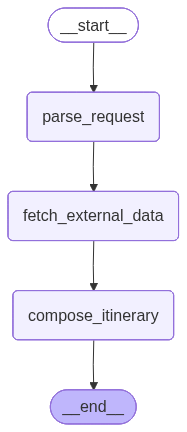

In [6]:
# Display helpers for notebook rendering
from IPython.display import Markdown, Image, display

# Build visual graph representation from the compiled LangGraph workflow
workflow = agent.graph.get_graph()
mermaid_text = workflow.draw_mermaid()

# Show section title and Mermaid source (useful even if PNG rendering fails)
display(Markdown("## 3.2 LangGraph Workflow (Visual)"))

# Try rendering PNG directly in notebook for presentation convenience
try:
    png_bytes = workflow.draw_mermaid_png()
    display(Image(data=png_bytes))
except Exception as exc:
    print(
        "Image render unavailable in this environment. Mermaid text above is the visual source."
    )
    print(f"Details: {exc}")

## 4. Example A: Normal Run

Concept:

- Start with a healthy run so the audience learns the baseline trace.
- This run calls free weather + free web search tools.

Explain while presenting:

- request input
- itinerary output
- token and cost summary
- where to find this run in Agents View


In [7]:
# Example A: healthy run (baseline trace)
request = "Plan a short Tokyo trip with good hotels"

# Execute run with tracing metadata attached
result = run_agent_with_tracing(request)

# Enforce real LLM usage in demo examples
if result["input_tokens"] <= 0 or result["output_tokens"] <= 0:
    raise RuntimeError(
        "Expected real LLM token usage, but tokens are zero. Check model/provider configuration."
    )

# Presenter-friendly output
print("Request:", request)
print("-" * 40)
print(result["itinerary"])

print("\nTelemetry Summary")
print(f"Input tokens:  {result['input_tokens']}")
print(f"Output tokens: {result['output_tokens']}")
print(f"Estimated cost: ${result['cost_usd']:.6f}")

Request: Plan a short Tokyo trip with good hotels
----------------------------------------
Day 1:
- Morning: Visit Asakusa and explore Senso-ji Temple.
- Afternoon: Walk around Ueno Park and visit Tokyo National Museum.
- Evening: Dinner in Akihabara, enjoy the vibrant nightlife.

Day 2:
- Morning: Explore Tsukiji Outer Market for fresh seafood breakfast.
- Afternoon: Visit the Imperial Palace East Gardens.
- Evening: Stroll through Ginza for shopping and dining.

Day 3:
- Morning: Take a trip to Shibuya, see the famous crossing and Hachiko statue.
- Afternoon: Explore Harajuku and Meiji Shrine.
- Evening: Relax at Roppongi Hills with city views.

Packing tips: Wear light layers and comfortable shoes; carry an umbrella just in case. Weather is mainly clear with mild temperatures, ideal for morning to afternoon activities.

Telemetry Summary
Input tokens:  261
Output tokens: 178
Estimated cost: $0.000008


## 5. Example B: Failure Run

Concept:

- We force a tool failure (`fail_hotel`) to show error spans and failure context.
- In the current agent implementation this simulates web search tool failure.

Explain while presenting:

- what failed
- how the trace still captures full run context
- how to compare this run with the normal baseline


In [ ]:
# Example B: forced failure run (compare with baseline)
failure_request = "Plan a short Tokyo trip fail_hotel"

# The 'fail_hotel' token triggers simulated web search tool failure in demo agent
failure_result = run_agent_with_tracing(failure_request)

# Enforce real LLM usage in demo examples
if failure_result["input_tokens"] <= 0 or failure_result["output_tokens"] <= 0:
    raise RuntimeError(
        "Expected real LLM token usage, but tokens are zero. Check model/provider configuration."
    )

# Enforce failure signal so this demo is truly a failure scenario
if not failure_result.get("tool_failure", False):
    raise RuntimeError(
        "Failure scenario did not trigger. Ensure request contains 'fail_hotel'."
    )

# Presenter-friendly output
print("Request:", failure_request)
print("-" * 40)
print(failure_result["itinerary"])
print("\nFailure captured:", failure_result.get("tool_failure", False))
print("Failure reason:", failure_result.get("tool_failure_reason", "<none>"))

print("\nTelemetry Summary")
print(f"Input tokens:  {failure_result['input_tokens']}")
print(f"Output tokens: {failure_result['output_tokens']}")
print(f"Estimated cost: ${failure_result['cost_usd']:.6f}")

Request: Plan a short Tokyo trip fail_hotel
----------------------------------------
Day 1:
- Morning: Visit Asakusa and Senso-ji Temple; enjoy the clear weather and explore Nakamise shopping street.
- Afternoon: Head to Ueno Park and visit museums or the zoo.
- Evening: Dinner in Akihabara, explore electronics shops and anime culture.

Day 2:
- Morning: Explore Tsukiji Outer Market for fresh seafood breakfast.
- Afternoon: Visit the Imperial Palace East Gardens and nearby Marunouchi district.
- Evening: Experience Shibuya Crossing and dine in nearby restaurants.

Day 3:
- Morning: Take a stroll in Meiji Shrine and Yoyogi Park.
- Afternoon: Shop and explore Harajuku’s Takeshita Street.
- Evening: Enjoy panoramic city views from Tokyo Tower or Roppongi Hills.

Packing tips: Wear light layers and comfortable shoes for walking. Weather is mainly clear with mild temperatures (9-21°C). Carry an umbrella just in case.

Telemetry Summary
Input tokens:  223
Output tokens: 199
Estimated cost: $

## 6. Example C: Multiple Runs for Search and Filters

Concept:

- Generate several runs so filtering and sorting in Agents View becomes meaningful.

Explain while presenting:

- compare normal vs failure runs
- compare token/cost across runs
- show how thread/run IDs help isolate conversations


In [ ]:
# Example C: generate multiple runs for search/sort/filter demo in Agents View
requests = [
    "Plan a short Tokyo trip",
    "Plan a short Paris trip",
    "Plan a short Tokyo trip fail_hotel",
]

for i, req in enumerate(requests, start=1):
    # Each run gets unique run_id/thread_id metadata from helper function
    r = run_agent_with_tracing(req)
    if r["input_tokens"] <= 0 or r["output_tokens"] <= 0:
        raise RuntimeError(
            f"Run {i} did not report real LLM usage tokens. Check model/provider configuration."
        )
    print(f"Run {i}: {req}")
    print(
        f"  tokens_in={r['input_tokens']} tokens_out={r['output_tokens']} cost=${r['cost_usd']:.6f}"
    )

## 7. Cleanup

Concept:

- Flush telemetry exporter so all spans are sent before ending the demo.

Presenter note:

- Run this once at the end.


In [ ]:
# Cleanup: flush exporter only when custom fallback tracer is active
# (Foundry tracer handles export lifecycle internally)
if instrumentation:
    instrumentation.shutdown()
    print("Telemetry flushed")
else:
    print("No remote exporter configured (local run only).")